In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS

In [2]:
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [3]:
action_low = env.action_space.low[:4]
action_high = env.action_space.high[:4]
action_bounds = (action_low, action_high)

In [4]:
params = SB3_PARAMS
hidden_sizes = [256, 256]

In [5]:
random_seed = 0

In [6]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [7]:
sac = from_dict(env=env, hidden_sizes=hidden_sizes, action_bounds=action_bounds, **params)

In [8]:
agent = sac
agent_name = "SAC"

In [9]:
filepath = f"./defense/{agent_name}-{env_name}-{random_seed}"

In [11]:
# state = torch.load(f'{filepath}-{3639}.pth')
# agent.restore_state(state)

In [12]:
scaling = np.asarray([ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4.0 ,4.0])

In [22]:
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [23]:
for i in range(5):
    o, info = env.reset()
    o /= scaling
    env.render()
    
    for _ in range(1000):
        env.render()
        a1 = agent.act(o, noise_scale=0.) # np.random.uniform(-1,1,4)
        # a1 = np.random.uniform(-1, 1, 4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

In [24]:
env.close()

In [18]:
losses = []
rewards = []
i_episode = 0
env_name = "Defense"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [19]:
max_timesteps = 1000
new_episodes = 500
log_interval = 10
train_interval = 20

In [97]:
agent.alpha = 0.01

In [98]:
for i in range(new_episodes):
    total_reward = 0
    o, info = env.reset()
    o /= scaling
    # env.render()

    for j in range(max_timesteps):
        # env.render()
        a1 = agent.act(o) # np.random.uniform(-1,1,4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        if j % train_interval == 0:
            loss = agent.train()
            losses.append(loss)
        total_reward += r
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

    i_episode += 1
    
    rewards.append(total_reward)
    if (i_episode+1) % log_interval == 0:
        print(i_episode+1, np.mean(rewards[-10:]))

3150 -4.268137769833941
3160 -3.5480666856677643
3170 0.8267323316595698
3180 1.560296880629377
3190 -3.823572704042011
3200 3.6935015798099284
3210 -0.3848276405688857
3220 -4.192818275165682
3230 -0.7553141839168551
3240 -0.4138907803060173
3250 1.6962572405256584
3260 -1.8044424296344197
3270 0.19126846563221492
3280 1.358271327127357
3290 -1.7280832017451195
3300 -0.3727798645521818
3310 0.13123127232901605
3320 -7.261590198135647
3330 -0.7218721202199345
3340 1.8749850200347602
3350 0.27567887075661907
3360 0.9101365972683826
3370 -0.4754764482155857
3380 -3.4458717410396593
3390 2.339112720850521
3400 -1.3510771209174488
3410 2.1140345526860544
3420 1.8480349310099506
3430 -4.481786007353767
3440 2.0530287948507713
3450 1.9401075032696233
3460 -4.103956343071607
3470 -1.0044196533786167
3480 0.6938923781258017
3490 0.5873754574967711
3500 2.0009088388409313
3510 0.8258356113993006
3520 2.3088990028446195
3530 -0.23812352073815218
3540 -1.560209560426171
3550 -1.8464275921288849
3

In [110]:
print("########## Saving a checkpoint... ##########")
torch.save(agent.state(), f'{filepath}-{i_episode}.pth')

########## Saving a checkpoint... ##########


In [111]:
from sac.utils import save_statistics
save_statistics(filepath, rewards, [], losses)

In [99]:
plot_path = "defense"

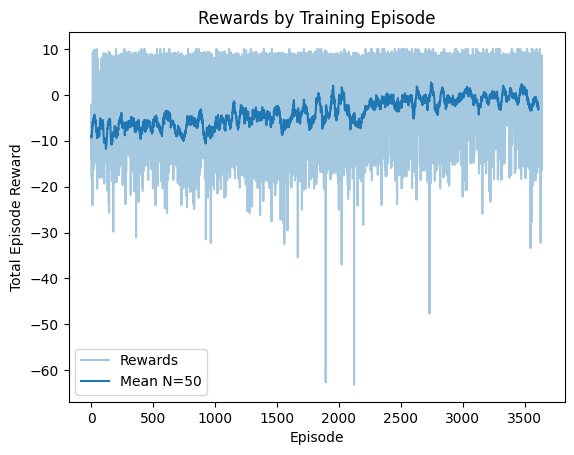

In [100]:
plot_rewards(rewards, plot_path, 30)

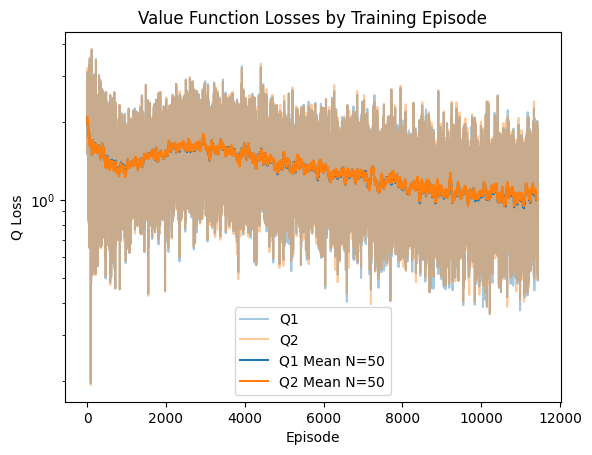

In [101]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

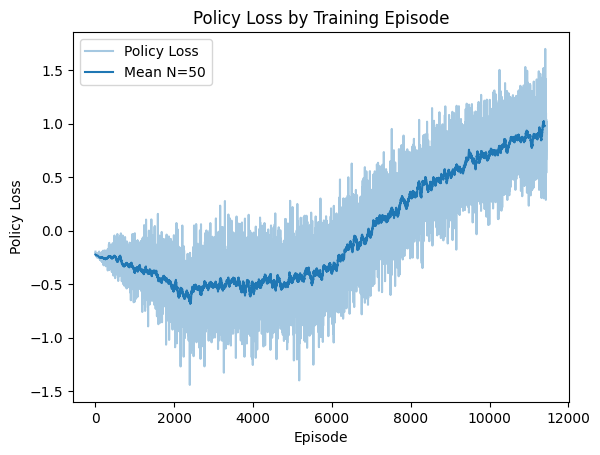

In [102]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

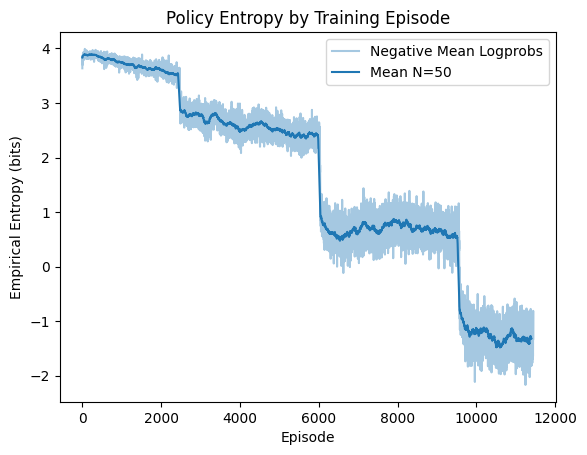

In [103]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)